### Breast Cancer Classification with a simple Neural Network(NN)

#### importing the Dependencies

In [52]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

#### Data collection & Processing

In [53]:
# loading the data from sklearn
breast_cancer_dataset = sklearn.datasets.load_breast_cancer()

In [54]:
print(breast_cancer_dataset)

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]], shape=(569, 30)), 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0,

In [55]:
# loading the data to a data frame
data_frame = pd.DataFrame(breast_cancer_dataset.data, columns=breast_cancer_dataset.feature_names)

In [56]:
# print the first 5 rows of the dataframe
data_frame.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [57]:
# adding the 'target' column to the dataframe
data_frame['target'] = breast_cancer_dataset.target

In [58]:
# print last 5 rows of the dataframe
data_frame.tail()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


In [59]:
# number of rows and columns in the dataset
data_frame.shape

(569, 31)

In [60]:
# getting some information about the dataset
data_frame.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [61]:
# checking for missing values in the dataset    
data_frame.isnull().sum()

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

In [62]:
# statistical measure about the data
data_frame.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [63]:
# checking the  distribution of Target Variable
data_frame['target'].value_counts()


target
1    357
0    212
Name: count, dtype: int64

#### 1-> Benign
#### 2-> Malignant

In [64]:
data_frame.groupby('target').mean()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
target,,,,,,,,,,,,,,,,,,,,,
0,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,21.134811,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530
1,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,13.379801,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442


#### Separating the feature and target

In [65]:
X = data_frame.drop(columns='target')
Y = data_frame['target']

In [66]:
print(X)

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0          17.99         10.38          122.80     1001.0          0.11840   
1          20.57         17.77          132.90     1326.0          0.08474   
2          19.69         21.25          130.00     1203.0          0.10960   
3          11.42         20.38           77.58      386.1          0.14250   
4          20.29         14.34          135.10     1297.0          0.10030   
..           ...           ...             ...        ...              ...   
564        21.56         22.39          142.00     1479.0          0.11100   
565        20.13         28.25          131.20     1261.0          0.09780   
566        16.60         28.08          108.30      858.1          0.08455   
567        20.60         29.33          140.10     1265.0          0.11780   
568         7.76         24.54           47.92      181.0          0.05263   

     mean compactness  mean concavity  mean concave points  mea

In [67]:
print(Y)

0      0
1      0
2      0
3      0
4      0
      ..
564    0
565    0
566    0
567    0
568    1
Name: target, Length: 569, dtype: int64


#### Splitting the data into training data & Testing data

In [68]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [69]:
print(X.shape, X_train, X_test.shape)

(569, 30)      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
560        14.05         27.15           91.38      600.4          0.09929   
428        11.13         16.62           70.47      381.1          0.08151   
198        19.18         22.49          127.50     1148.0          0.08523   
203        13.81         23.75           91.56      597.8          0.13230   
41         10.95         21.35           71.90      371.1          0.12270   
..           ...           ...             ...        ...              ...   
299        10.51         23.09           66.85      334.2          0.10150   
534        10.96         17.62           70.79      365.6          0.09687   
493        12.46         12.83           78.83      477.3          0.07372   
527        12.34         12.27           78.94      468.5          0.09003   
168        17.47         24.68          116.10      984.6          0.10490   

     mean compactness  mean concavity  mean concave p

Building the Neural Network

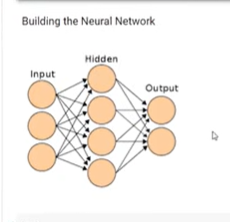

In [70]:
# importing tensorflow and keras
import tensorflow as tf
tf.random.set_seed(3)
from tensorflow import keras

In [71]:
# Setting up the layers of Neural Network

model = keras.Sequential([
    keras.layers.Flatten(input_shape=(30,)),
    keras.layers.Dense(20, activation='relu'),
    keras.layers.Dense(2, activation='sigmoid')
])

c:\Users\USER\ml_tf\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [72]:
# compiling the neural network
model.compile(optimizer ='adam',
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [82]:
# training the neural network
history = model.fit(X_train, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3692 - loss: 126.9338 - val_accuracy: 0.3478 - val_loss: 61.0425
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3692 - loss: 26.1747 - val_accuracy: 0.3478 - val_loss: 12.9892
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3692 - loss: 6.1975 - val_accuracy: 0.3478 - val_loss: 0.5493
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3692 - loss: 2.0761 - val_accuracy: 0.3478 - val_loss: 2.4896
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3692 - loss: 1.0919 - val_accuracy: 0.3478 - val_loss: 0.4407
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3692 - loss: 0.5916 - val_accuracy: 0.3478 - val_loss: 0.3784
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3692 - loss: 0.4285 - val_accuracy: 0.3478 - val_loss: 0.2686
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3692 - loss: 0.3563 - val_accuracy: 0.3478 - 

#### Standarize the data

In [75]:
from sklearn.preprocessing import StandardScaler

In [76]:
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
x_test_std = scaler.transform(X_test)

In [77]:
print(X_train_std)

[[-0.01330339  1.7757658  -0.01491962 ... -0.13236958 -1.08014517
  -0.03527943]
 [-0.8448276  -0.6284278  -0.87702746 ... -1.11552632 -0.85773964
  -0.72098905]
 [ 1.44755936  0.71180168  1.47428816 ...  0.87583964  0.4967602
   0.46321706]
 ...
 [-0.46608541 -1.49375484 -0.53234924 ... -1.32388956 -1.02997851
  -0.75145272]
 [-0.50025764 -1.62161319 -0.527814   ... -0.0987626   0.35796577
  -0.43906159]
 [ 0.96060511  1.21181916  1.00427242 ...  0.8956983  -1.23064515
   0.50697397]]


In [84]:
# training the neural network
history = model.fit(X_train_std, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9193 - loss: 0.1964 - val_accuracy: 0.9565 - val_loss: 0.1695
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9438 - loss: 0.1721 - val_accuracy: 0.9783 - val_loss: 0.1399
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9511 - loss: 0.1506 - val_accuracy: 0.9783 - val_loss: 0.1190
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9535 - loss: 0.1347 - val_accuracy: 0.9783 - val_loss: 0.1049
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9609 - loss: 0.1230 - val_accuracy: 0.9783 - val_loss: 0.0949
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9658 - loss: 0.1140 - val_accuracy: 0.9783 - val_loss: 0.0875
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9682 - loss: 0.1068 - val_accuracy: 0.9783 - val_loss: 0.0817
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9682 - loss: 0.1008 - val_accuracy: 0.9783 - va

#### Visualizing accuracy and loss

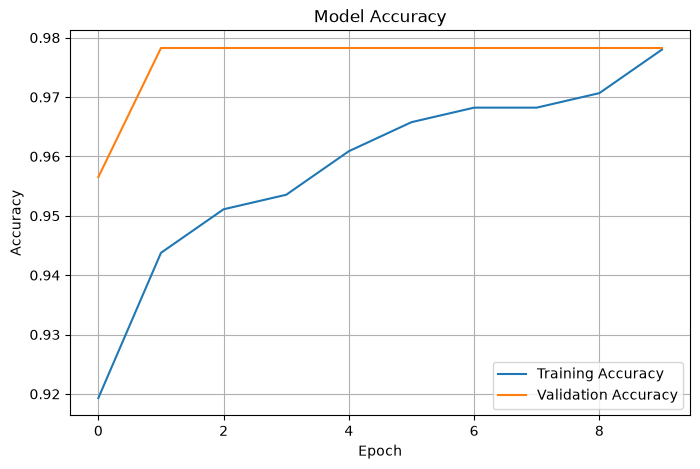

In [112]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(loc='lower right')
plt.grid(True)

plt.show()

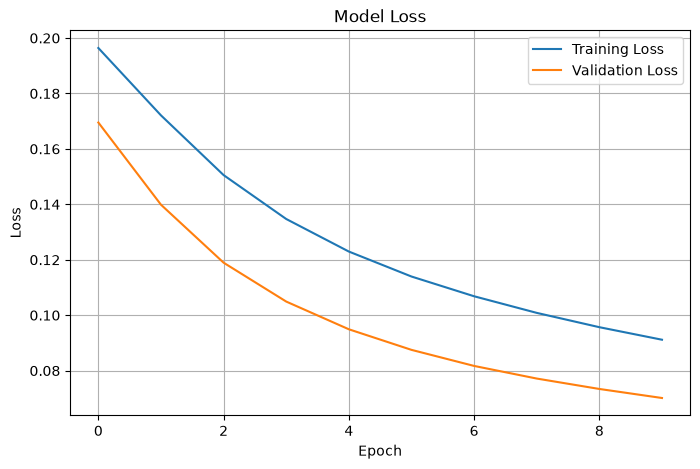

In [113]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(loc='upper right')
plt.grid(True)

plt.show()

#### Accuracy of the model on test data

In [87]:
loss , accuracy = model.evaluate(x_test_std, Y_test)
print(accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9649 - loss: 0.1049
0.9649122953414917


In [88]:
print(x_test_std.shape)
print(x_test_std[0])

(114, 30)
[-0.04462793 -1.41612656 -0.05903514 -0.16234067  2.0202457  -0.11323672
  0.18500609  0.47102419  0.63336386  0.26335737  0.53209124  2.62763999
  0.62351167  0.11405261  1.01246781  0.41126289  0.63848593  2.88971815
 -0.41675911  0.74270853 -0.32983699 -1.67435595 -0.36854552 -0.38767294
  0.32655007 -0.74858917 -0.54689089 -0.18278004 -1.23064515 -0.6268286 ]


In [92]:
Y_pred = model.predict(x_test_std)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [93]:
print(Y_pred.shape)
print(Y_pred[0])

(114, 2)
[0.60172546 0.8947536 ]


In [95]:
print(x_test_std)

[[-0.04462793 -1.41612656 -0.05903514 ... -0.18278004 -1.23064515
  -0.6268286 ]
 [ 0.24583601 -0.06219797  0.21802678 ...  0.54129749  0.11047691
   0.0483572 ]
 [-1.26115925 -0.29051645 -1.26499659 ... -1.35138617  0.269338
  -0.28231213]
 ...
 [ 0.72709489  0.45836817  0.75277276 ...  1.46701686  1.19909344
   0.65319961]
 [ 0.25437907  1.33054477  0.15659489 ... -1.29043534 -2.22561725
  -1.59557344]
 [ 0.84100232 -0.06676434  0.8929529  ...  2.15137705  0.35629355
   0.37459546]]


In [96]:
print(Y_pred)

[[0.60172546 0.8947536 ]
 [0.4992055  0.50193137]
 [0.01135237 0.96383226]
 [0.9998985  0.01069743]
 [0.41668597 0.66386235]
 [0.9925018  0.05609157]
 [0.19612536 0.8328659 ]
 [0.027504   0.96870786]
 [0.07321031 0.9147498 ]
 [0.09914152 0.91293454]
 [0.48018703 0.43866906]
 [0.10289365 0.75558305]
 [0.14029922 0.9331738 ]
 [0.14469592 0.7854842 ]
 [0.04515084 0.9517257 ]
 [0.9804176  0.39838028]
 [0.02962434 0.9378591 ]
 [0.0450309  0.9612898 ]
 [0.05327654 0.9796646 ]
 [0.9853953  0.04022048]
 [0.3574989  0.98896885]
 [0.03865719 0.9574713 ]
 [0.07480706 0.8668229 ]
 [0.03901577 0.96816635]
 [0.16351786 0.91130567]
 [0.9063868  0.16683991]
 [0.10823874 0.8825499 ]
 [0.16653056 0.8556885 ]
 [0.8767123  0.4078454 ]
 [0.93075424 0.23602086]
 [0.2300351  0.79943395]
 [0.10124715 0.8882322 ]
 [0.06156421 0.9577012 ]
 [0.99792343 0.07800014]
 [0.96153206 0.0672825 ]
 [0.13706613 0.89231485]
 [0.02657131 0.9204887 ]
 [0.2511396  0.62884426]
 [0.02169824 0.97644246]
 [0.04689441 0.922314  ]


#### model.predict() gives the predication probability of each class for that data point

In [97]:
# argmax function
my_list = [10,20,30]

index_of_max_value =np.argmax(my_list)
print(my_list)
print(index_of_max_value)

[10, 20, 30]
2


In [105]:
# converting the prediction probability to class labels
Y_pred_labels = [np.argmax(i) for i in Y_pred]
print(Y_pred_labels)

[np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1)

#### building the predictive system

In [106]:
# Input data for one patient
input_data = (
    17.99,      # mean radius
    10.38,      # mean texture
    122.80,     # mean perimeter
    1001.0,     # mean area
    0.11840,    # mean smoothness
    0.27760,    # mean compactness
    0.30010,    # mean concavity
    0.14710,    # mean concave points
    0.24190,    # mean symmetry
    0.07871,    # mean fractal dimension
    1.0950,     # radius error
    0.9053,     # texture error
    8.589,      # perimeter error
    153.40,     # area error
    0.006399,   # smoothness error
    0.04904,    # compactness error
    0.05373,    # concavity error
    0.01587,    # concave points error
    0.03003,    # symmetry error
    0.006193,   # fractal dimension error
    25.38,      # worst radius
    17.33,      # worst texture
    184.60,     # worst perimeter
    2019.0,     # worst area
    0.1622,     # worst smoothness
    0.6656,     # worst compactness
    0.7119,     # worst concavity
    0.2654,     # worst concave points
    0.4601,     # worst symmetry
    0.11890     # worst fractal dimension
)

# Convert input data to NumPy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape for one data point
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Standardize the input data
input_data_std = scaler.transform(input_data_reshaped)

# Make prediction
prediction = model.predict(input_data_std)

print("Prediction:", prediction)

# Get predicted class
prediction_label = [np.argmax(prediction)]

print("Prediction Label:", prediction_label)

# Display result
if prediction_label[0] == 0:
    print("The Tumor is Malignant")
else:
    print("The Tumor is Benign")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Prediction: [[0.9972891  0.11381584]]
Prediction Label: [np.int64(0)]
The Tumor is Malignant


c:\Users\USER\ml_tf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [107]:
# Sample input data for a BENIGN tumor
input_data = (
    11.42, 20.38, 77.58, 386.1, 0.1425,
    0.2839, 0.2414, 0.1052, 0.2597, 0.09744,
    0.4956, 1.156, 3.445, 27.23, 0.00911,
    0.07458, 0.05661, 0.01867, 0.05963, 0.009208,
    14.91, 26.50, 98.87, 567.7, 0.2098,
    0.8663, 0.6869, 0.2575, 0.6638, 0.1730
)

# Convert to NumPy array
input_data_as_numpy_array = np.asarray(input_data)

# Reshape for one prediction
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# Standardize
input_data_std = scaler.transform(input_data_reshaped)

# Prediction
prediction = model.predict(input_data_std)

print("Prediction:", prediction)

# Get predicted class
prediction_label = [np.argmax(prediction)]

print("Prediction Label:", prediction_label)

# Display result
if prediction_label[0] == 0:
    print("The Tumor is Malignant")
else:
    print("The Tumor is Benign")

c:\Users\USER\ml_tf\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step
Prediction: [[0.88517386 0.46430594]]
Prediction Label: [np.int64(0)]
The Tumor is Malignant
